<a href="https://colab.research.google.com/github/DanuAlamsyah/Pengolahan-Citra/blob/main/Tugas5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Menghitung jarak berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


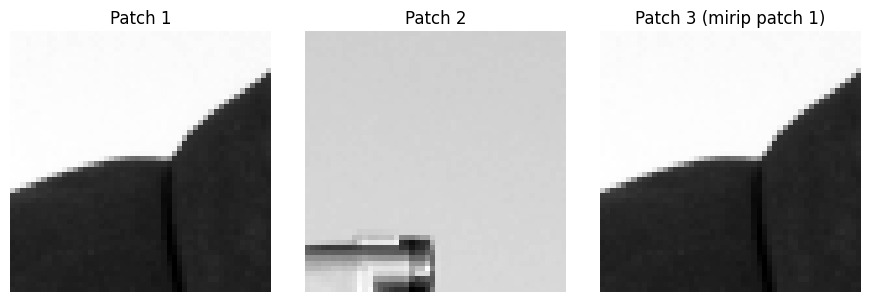

In [ ]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

#1.buat 2 patch citra/ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] #patch dari lokasi berbeda
patch3 = patch1 + 0.1 #patch1 sedikit noise
patch3 = np.clip(patch3, 0, 1) # nilai tetap di [0, 1]

#2.flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

#3.hitung jarak Euclidean (L2)
dist_12_12 = distance.euclidean(vec1, vec2)
dist_12_13 = distance.euclidean(vec1, vec3)

# 4.hitung Jarak Manhattan (L1)
dist_11_12 = distance.cityblock(vec1, vec2)
dist_11_13 = distance.cityblock(vec1, vec3)

#5.tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_12_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_12_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_11_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_11_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (mirip patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

2.Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


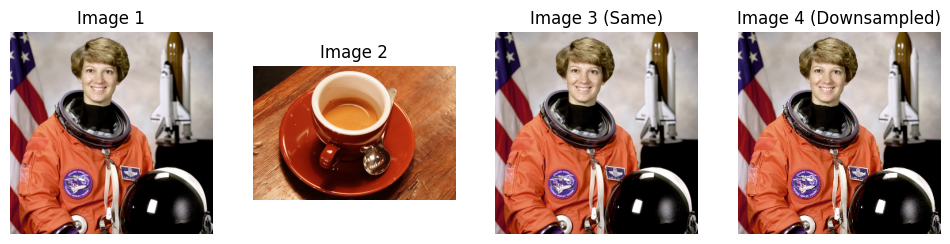

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

#fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

#1.muat dua citra berwarna
try:
    #citra berbeda dari skimage/file
    image1 = data.astronaut()
    image2 = data.coffee() #citra yang berbeda
    image3 = data.astronaut() #citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :] #versi downsampled image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2,::2,:]

#2.hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

#3.hitung Cosine Similarity (1 - Cosine Distance)
# scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

#4.tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

#visualisasi
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1);
axes[0].axis('off')
axes[1].imshow(image2);
axes[1].axis('off')
axes[2].imshow(image3);
axes[0].set_title('Image 1');
axes[1].set_title('Image 2');
axes[2].set_title('Image 3 (Same)');
axes[2].axis('off')
axes[3].imshow(image4);
axes[3].set_title('Image 4 (Downsampled)');
axes[3].axis('off')
plt.show()

3.Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2952
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


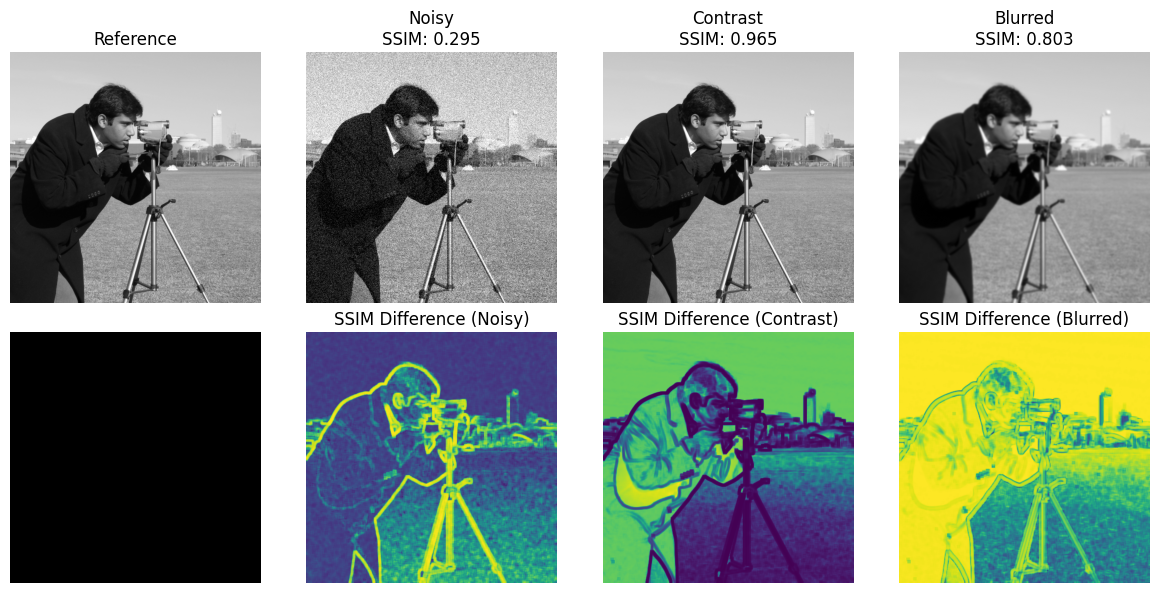

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

#1.muat citra referensi
image_ref = img_as_float(data.camera())

#2.buat beberapa versi citra yang 'terdistorsi'
# a)citra yang sama (SSIM harus 1)
image_same = image_ref.copy()
# b)citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
# c)citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
# d)citra yang di-blur
from skimage.filters import gaussian
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None) # channel_axis=None jika grayscale

#3.hitung SSIM antara citra referensi dan citra terdistorsi
#SSIM memerlukan data_range
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)
# 'full=True' mengembalikan citra perbedaan SSIM juga

#4.tampilkan hasil SSIM dan citra perbedaan
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('Reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')

#menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title(''); ax[4].axis('off') # Placeholder
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM Difference (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Difference (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM Difference (Blurred)'); ax[7].axis('off')

plt.tight_layout()
plt.show()

4.Penerapan Template Matching

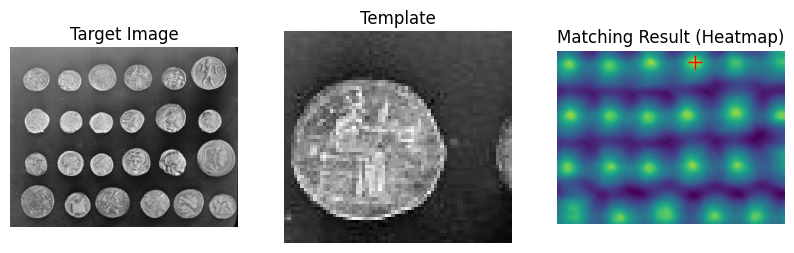

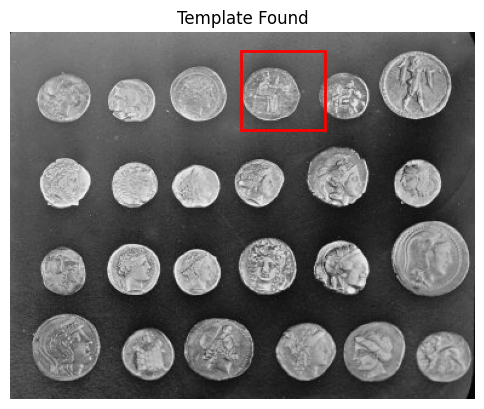

Template ditemukan di koordinat (x,y): (190, 15)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

#1.muat citra target dan buat/muat citra template
image = data.coins()
#mengambil salah satu koin sebagai template
template = image[15:80, 190:260]

#2.lakukan template matching dengan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

#3.temukan lokasi dengan skor matching tertinggi
#np.argmax menemukan indeks linear, unravel_index mengubahnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1] # Koordinat (x, y) dari sudut kiri atas template yang cocok

#4.visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

#menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
#tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10) # y, x karena ij adalah (row, col)

#menampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

5.Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


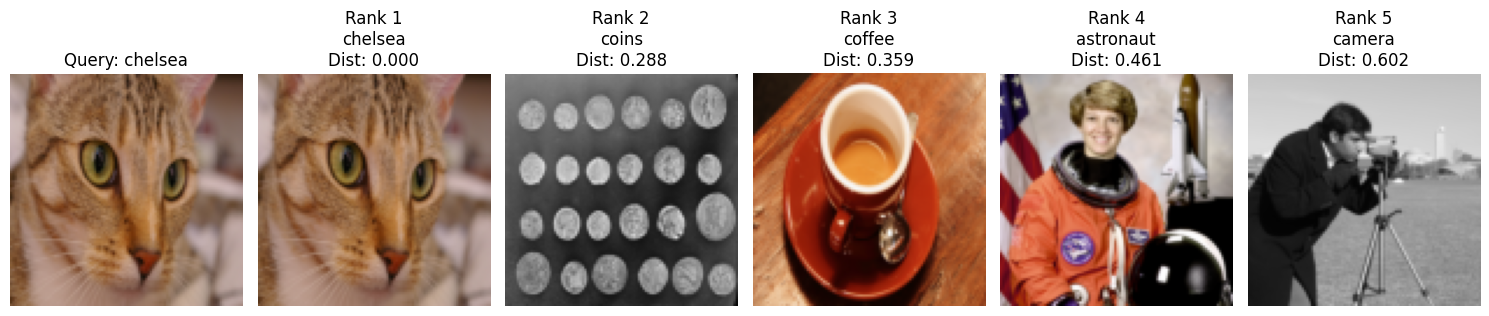

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float
from scipy.spatial import distance

#fungsi hitung histogram dari Praktikum 2
def calculate_rgb_histogram(image, bins=16):
    #memastikan input float [0,1] dikonversi ke uint8 [0,255] untuk histogram
    if image.dtype == float:
        image = img_as_ubyte(image)

    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))

    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    #normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float) # Avoid division by zero

    return hist_combined

#1.siapkan 'database' citra kecil dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        #semua citra berwarna (RGB) dan ukuran sama (opsional, resize)
        if img.ndim == 2: #jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        #resize agar ukuran fitur konsisten (misal 100x100)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

#pilih satu citra sebagai query (misal, 'chelsea' si kucing)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

#2.hitung jarak/kemiripan antara query dan semua citra di database
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

#3.urutkan citra berdasarkan jarak (dari terkecil ke terbesar)
sorted_indices = np.argsort(distances)

#4.tampilkan hasil: Query dan citra terurut berdasarkan kemiripan
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

#tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

#tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

# TUGAS

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


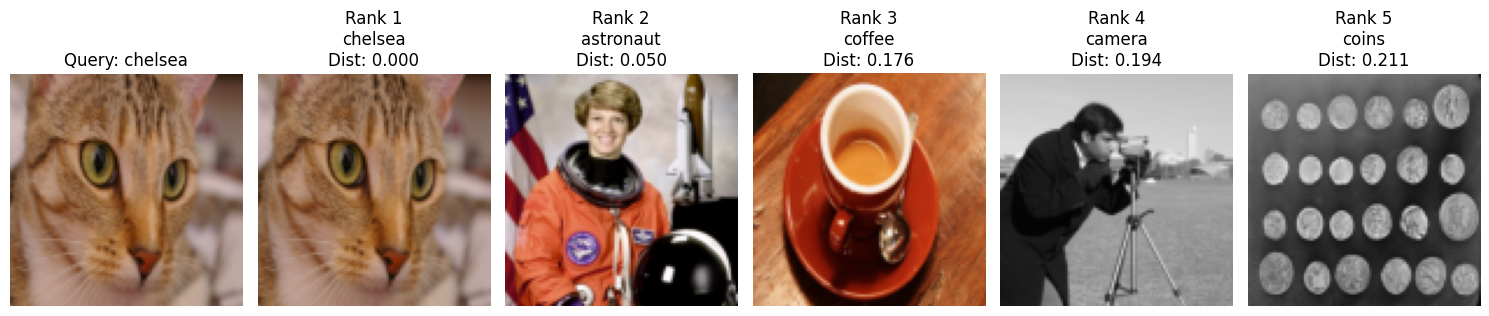

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float
from scipy.spatial import distance

#fungsi hitung rata-rata warna RGB
def calculate_mean_rgb(image):
    #image dalam float [0,1]
    if image.dtype != np.float32 and image.dtype != np.float64:
        image = img_as_float(image)
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

#1.siapkan 'database' citra kecil dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        #semua citra RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        feature_vector = calculate_mean_rgb(img_resized)
        database_features.append(feature_vector)
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

#pilih satu citra sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

#2.hitung jarak Euclidean antara query dan semua citra
distances = []
for i, feat in enumerate(database_features):
    dist = distance.euclidean(query_feature, feat)
    distances.append(dist)

#3.urutkan citra berdasarkan kemiripan (jarak kecil = lebih mirip)
sorted_indices = np.argsort(distances)

#4.tampilkan hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    ax = axes[i + 1]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {i+1}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


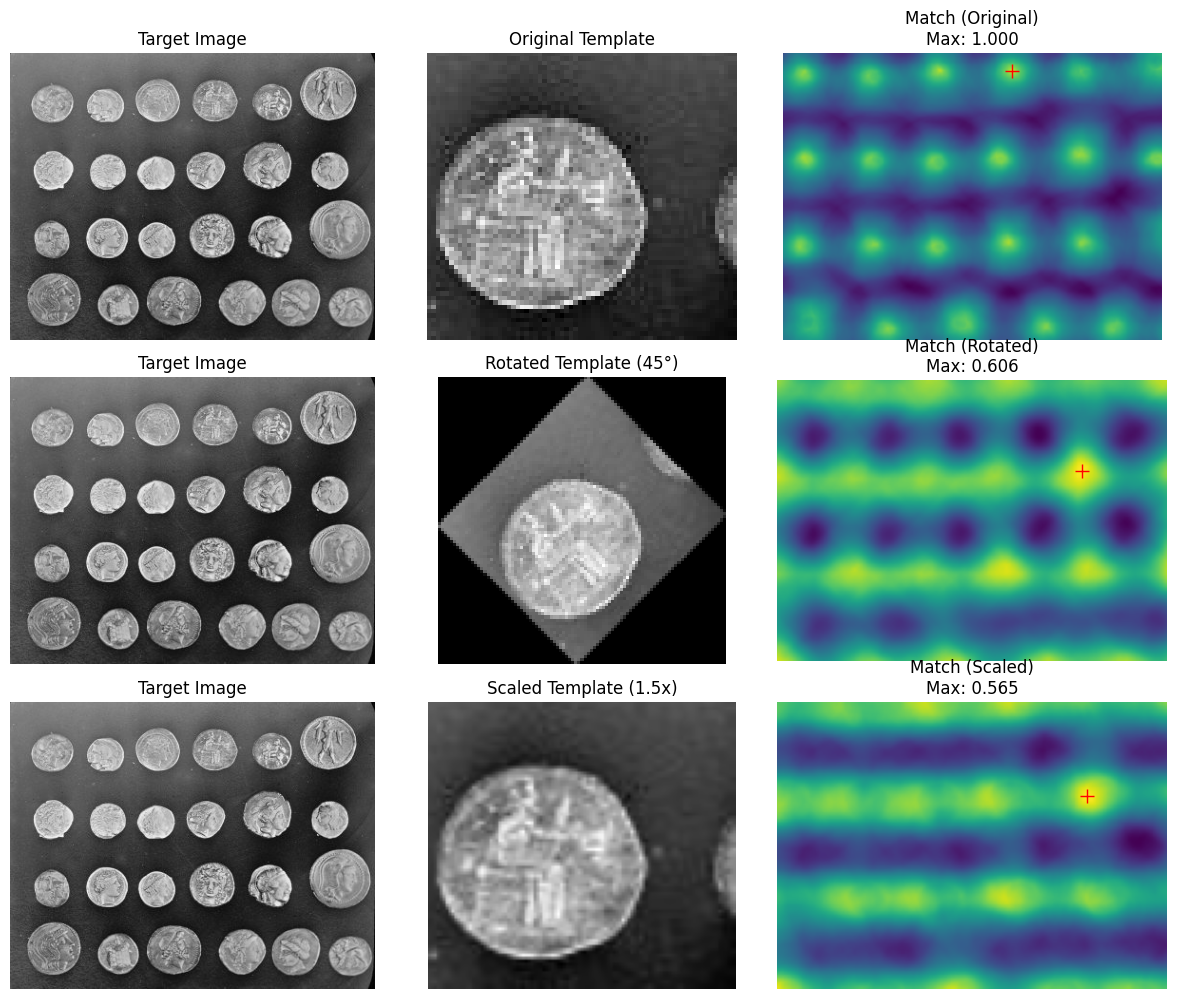

Original Match: (x, y) = (190, 15), Max Score = 1.000
Rotated Match:  (x, y) = (226, 67), Max Score = 0.606
Scaled Match:   (x, y) = (222, 67), Max Score = 0.565


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale
from skimage.util import img_as_float

#1.muat citra target dan ambil template
image = data.coins()
template = image[15:80, 190:260]

#2.buat template rotasi dan skala
rotated_template = rotate(template, angle=45, resize=True)
scaled_template = rescale(template, scale=1.5, anti_aliasing=True)

#3.matching dengan template asli
result_orig = match_template(image, template)
ij_orig = np.unravel_index(np.argmax(result_orig), result_orig.shape)
x_orig, y_orig = ij_orig[::-1]

#4.matching dengan template rotasi
result_rotated = match_template(image, rotated_template)
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x_rot, y_rot = ij_rotated[::-1]

#5.matching dengan template skala
result_scaled = match_template(image, scaled_template)
ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)
x_scl, y_scl = ij_scaled[::-1]

#6.visualisasi
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

#asli
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Target Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(template, cmap='gray')
axes[0, 1].set_title("Original Template")
axes[0, 1].axis('off')

axes[0, 2].imshow(result_orig, cmap='viridis')
axes[0, 2].plot(x_orig, y_orig, 'r+', markersize=10)
axes[0, 2].set_title(f"Match (Original)\nMax: {np.max(result_orig):.3f}")
axes[0, 2].axis('off')

#rotated
axes[1, 0].imshow(image, cmap='gray')
axes[1, 0].set_title("Target Image")
axes[1, 0].axis('off')

axes[1, 1].imshow(rotated_template, cmap='gray')
axes[1, 1].set_title("Rotated Template (45°)")
axes[1, 1].axis('off')

axes[1, 2].imshow(result_rotated, cmap='viridis')
axes[1, 2].plot(x_rot, y_rot, 'r+', markersize=10)
axes[1, 2].set_title(f"Match (Rotated)\nMax: {np.max(result_rotated):.3f}")
axes[1, 2].axis('off')

#scaled
axes[2, 0].imshow(image, cmap='gray')
axes[2, 0].set_title("Target Image")
axes[2, 0].axis('off')

axes[2, 1].imshow(scaled_template, cmap='gray')
axes[2, 1].set_title("Scaled Template (1.5x)")
axes[2, 1].axis('off')

axes[2, 2].imshow(result_scaled, cmap='viridis')
axes[2, 2].plot(x_scl, y_scl, 'r+', markersize=10)
axes[2, 2].set_title(f"Match (Scaled)\nMax: {np.max(result_scaled):.3f}")
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

#print hasil koordinat dan skor
print(f"Original Match: (x, y) = ({x_orig}, {y_orig}), Max Score = {np.max(result_orig):.3f}")
print(f"Rotated Match:  (x, y) = ({x_rot}, {y_rot}), Max Score = {np.max(result_rotated):.3f}")
print(f"Scaled Match:   (x, y) = ({x_scl}, {y_scl}), Max Score = {np.max(result_scaled):.3f}")
